# 03 - Preprocessing

Dựa trên `reports/dataset_intake_report.md`, xử lý dữ liệu trước khi train:

1. **Loại bỏ 64 ảnh thiếu annotation** trong bộ All_In_One - không dùng làm negative sample vì không chắc chắn ảnh đó thực sự không có người (annotation bị thiếu, khác với file annotation rỗng xác nhận 0 box).
2. **Dedupe ảnh trùng lặp (MD5)** - chỉ giữ 1 đại diện/nhóm để tránh data leakage giữa train/val/test.
3. Chia **train/val/test** theo tỷ lệ trong `configs/dataset.yaml` (80/10/10, seed 42).
4. **Tăng cường ảnh nhiệt chuyên biệt** (bilateral denoise + CLAHE trên kênh L) - xử lý đặc trưng riêng cho ảnh nhiệt, không phải augmentation ngẫu nhiên.
5. Xuất ra `data/processed/` theo cấu trúc chuẩn cho YOLOv8 (`images/{split}`, `labels/{split}`, `data.yaml`).

## 0. Setup

Đọc `configs/dataset.yaml`, lấy lại đường dẫn dataset từ cache (notebook 01).

In [1]:
import os
import csv
import random
import shutil
import hashlib
from collections import defaultdict

import yaml

with open("../configs/dataset.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

DATASET_SLUG = cfg["dataset"]["kaggle_slug"]
cache_dir = os.path.join(
    os.path.expanduser("~"), ".cache", "kagglehub", "datasets",
    *DATASET_SLUG.split("/"), "versions"
)
cached_versions = os.path.isdir(cache_dir) and os.listdir(cache_dir)
if not cached_versions:
    raise RuntimeError("Dataset chưa được tải. Chạy notebook 01_environment_and_dataset.ipynb trước.")
dataset_root = os.path.join(cache_dir, sorted(cached_versions)[-1])

image_dir = os.path.join(dataset_root, *cfg["annotations"]["image_dir"].split("/"))
yolo_dir = os.path.join(dataset_root, *cfg["annotations"]["yolo_dir"].split("/"))
CLASS_NAMES = [c["name"] for c in sorted(cfg["classes"], key=lambda c: c["id"])]

split_cfg = cfg["split"]
SEED = split_cfg["seed"]
random.seed(SEED)

PROCESSED_DIR = os.path.abspath("../data/processed")

print("Image dir:", image_dir)
print("YOLO dir (All_In_One):", yolo_dir)
print("Output dir:", PROCESSED_DIR)
print("Split config:", split_cfg)
print("Classes:", CLASS_NAMES)

Image dir: C:\Users\hotha\.cache\kagglehub\datasets\animeshmahajan\thermal-image-dataset\versions\1\ALL_IN_ONE_RGB_IMG_ANOT
YOLO dir (All_In_One): C:\Users\hotha\.cache\kagglehub\datasets\animeshmahajan\thermal-image-dataset\versions\1\ALL_IN_ONE_RGB_IMG_ANOT\Anotations\All_In_One_Anot_Yolo
Output dir: D:\Thermal_project\data\processed
Split config: {'train': 0.8, 'val': 0.1, 'test': 0.1, 'seed': 42}
Classes: ['Human']


## 1. Xây manifest ảnh hợp lệ (loại bỏ ảnh thiếu annotation)

Chỉ giữ ảnh có file `.txt` tương ứng trong bộ All_In_One - khớp với số liệu ở `reports/dataset_intake_report.md` (6.340 ảnh gốc, 64 thiếu annotation).

In [2]:
all_jpgs = sorted(f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg")))

valid_images = []
excluded_missing_annotation = []
for jpg in all_jpgs:
    stem = os.path.splitext(jpg)[0]
    txt_path = os.path.join(yolo_dir, stem + ".txt")
    if os.path.isfile(txt_path):
        valid_images.append(jpg)
    else:
        excluded_missing_annotation.append(jpg)

print(f"Tổng số ảnh gốc: {len(all_jpgs)}")
print(f"Loại bỏ (thiếu annotation All_In_One): {len(excluded_missing_annotation)}")
print(f"Còn lại sau khi loại bỏ: {len(valid_images)}")
assert len(valid_images) + len(excluded_missing_annotation) == len(all_jpgs)

Tổng số ảnh gốc: 6340
Loại bỏ (thiếu annotation All_In_One): 64
Còn lại sau khi loại bỏ: 6276


## 2. Dedupe ảnh trùng lặp (MD5)

Tính MD5 từng ảnh hợp lệ, gom nhóm theo hash giống hệt nhau, mỗi nhóm chỉ giữ 1 đại diện (file có tên nhỏ nhất) để tránh cùng một ảnh xuất hiện ở cả train và val/test.

*Lưu ý: số ảnh trùng lặp bị loại ở đây có thể khác con số "218 file" trong `reports/dataset_intake_report.md`, vì report tính trên toàn bộ 6.340 ảnh còn ở đây chỉ tính trên 6.276 ảnh hợp lệ (đã loại 64 ảnh thiếu annotation ở bước 1) - một vài cặp trùng lặp có thể có 1 ảnh nằm trong nhóm bị loại đó.*

In [3]:
hash_to_images = defaultdict(list)
image_to_hash = {}
for jpg in valid_images:
    with open(os.path.join(image_dir, jpg), "rb") as fh:
        h = hashlib.md5(fh.read()).hexdigest()
    hash_to_images[h].append(jpg)
    image_to_hash[jpg] = h

deduped_images = []
dropped_duplicates = {}  # file bị loại -> file đại diện được giữ lại
for h, files in hash_to_images.items():
    files_sorted = sorted(files)
    keep = files_sorted[0]
    deduped_images.append(keep)
    for dup in files_sorted[1:]:
        dropped_duplicates[dup] = keep

deduped_images = sorted(deduped_images)
print(f"Số nhóm MD5 duy nhất (ảnh giữ lại sau dedupe): {len(deduped_images)}")
print(f"Số ảnh trùng lặp bị loại: {len(dropped_duplicates)}")
assert len(deduped_images) + len(dropped_duplicates) == len(valid_images)

Số nhóm MD5 duy nhất (ảnh giữ lại sau dedupe): 6061
Số ảnh trùng lặp bị loại: 215


## 3. Chia train/val/test

Xáo trộn ngẫu nhiên (seed cố định từ config) rồi chia theo tỷ lệ - đảm bảo không có ảnh nào lặp giữa 3 tập.

In [4]:
shuffled = deduped_images.copy()
random.shuffle(shuffled)

n = len(shuffled)
n_train = round(n * split_cfg["train"])
n_val = round(n * split_cfg["val"])

train_files = shuffled[:n_train]
val_files = shuffled[n_train:n_train + n_val]
test_files = shuffled[n_train + n_val:]

splits = {"train": train_files, "val": val_files, "test": test_files}
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)} | Tổng: {n}")

assert not (set(train_files) & set(val_files))
assert not (set(train_files) & set(test_files))
assert not (set(val_files) & set(test_files))
print("Không có ảnh trùng giữa 3 tập (theo tên file).")

Train: 4849 | Val: 606 | Test: 606 | Tổng: 6061
Không có ảnh trùng giữa 3 tập (theo tên file).


## 4. Tăng cường ảnh nhiệt chuyên biệt (denoise + CLAHE)

EDA ở `02_dataset_analysis.ipynb` cho thấy dải sáng ảnh khá hẹp (~70-140/255) - ảnh nhiệt tương phản thấp hơn ảnh RGB thường và thường có nhiễu hạt (sensor grain) rõ hơn. Áp dụng 2 bước theo đúng thứ tự:

1. **Bilateral denoise trước** - giảm nhiễu cảm biến nhưng vẫn giữ biên vật thể nhỏ (người ở xa, bbox nhỏ theo phân tích ở notebook 02). Làm trước CLAHE để tránh CLAHE khuếch đại nhiễu.
2. **CLAHE trên kênh L (không gian màu LAB)** sau - tăng tương phản cục bộ. Áp trên kênh L thay vì từng kênh R/G/B riêng lẻ, vì đã verify tương quan kênh R-B âm (~-0.49) trên nhiều ảnh mẫu - đặc trưng của palette giả màu (false-color, kiểu ironbow/jet) áp lên **một kênh cường độ nhiệt duy nhất**, không phải RGB độc lập từng kênh. Nếu CLAHE từng kênh riêng sẽ làm lệch màu so với palette gốc.

Tham số (`clip_limit`, `tile_grid_size`, `d`, `sigma_color`, `sigma_space`) cấu hình trong `configs/dataset.yaml -> preprocessing`, implementation tại `src/datasets/preprocessing.py` (tái sử dụng được cho cả training và inference sau này). Xem trước/sau trên vài ảnh mẫu để kiểm tra trực quan trước khi áp dụng cho toàn bộ 6.061 ảnh.

Denoise params: {'d': 5, 'sigma_color': 50, 'sigma_space': 50}
CLAHE params: {'clip_limit': 2.0, 'tile_grid_size': [8, 8]}


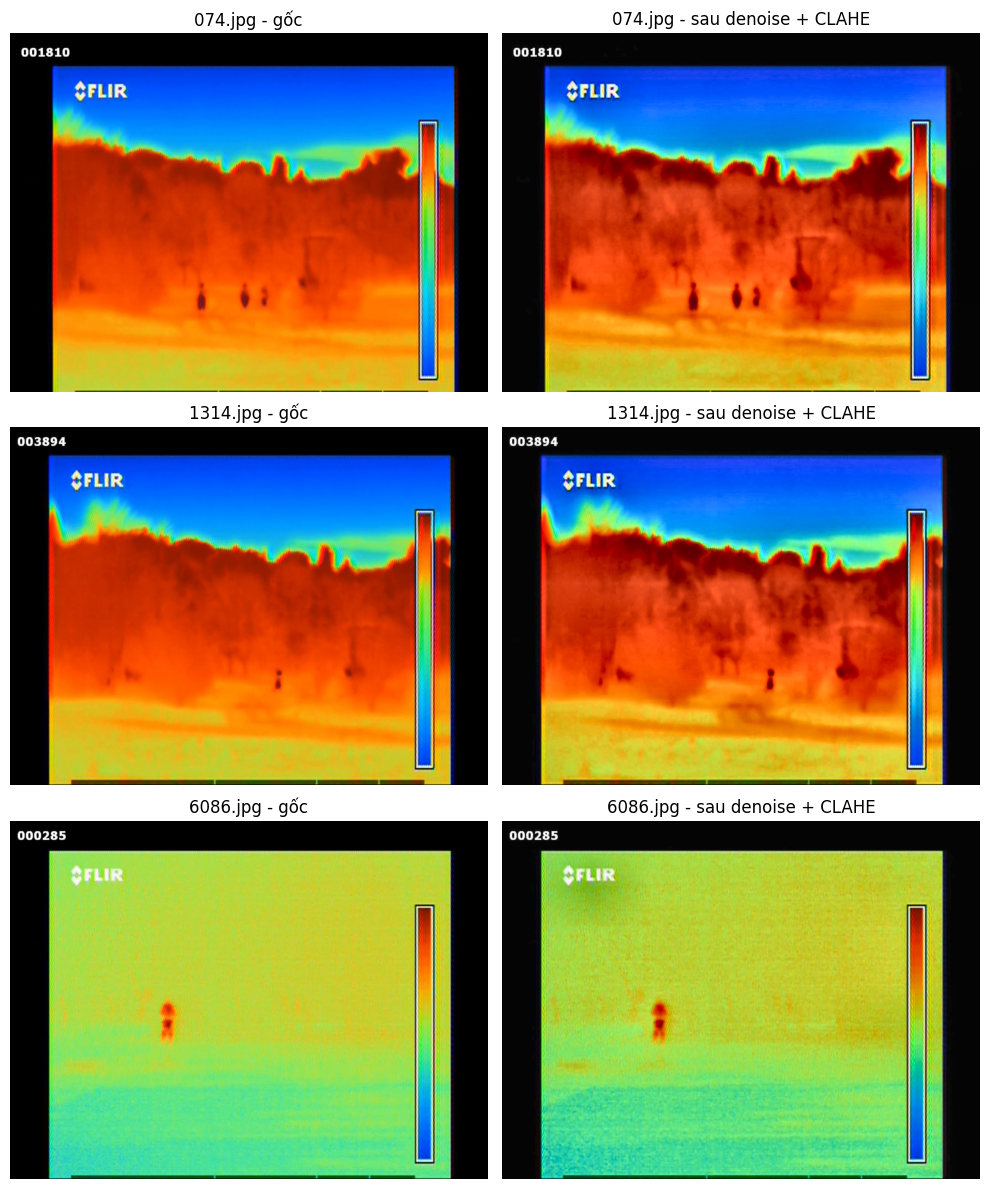

In [5]:
import sys
sys.path.insert(0, os.path.abspath(".."))
from src.datasets.preprocessing import preprocess_thermal_image

import cv2
import matplotlib.pyplot as plt

pre_cfg = cfg["preprocessing"]
denoise_params = {k: v for k, v in pre_cfg["denoise"].items() if k != "method"}
clahe_params = pre_cfg["clahe"]
print("Denoise params:", denoise_params)
print("CLAHE params:", clahe_params)

demo_samples = random.sample(deduped_images, 3)
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for row, jpg in enumerate(demo_samples):
    bgr = cv2.imread(os.path.join(image_dir, jpg))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    enhanced = preprocess_thermal_image(rgb, denoise_params, clahe_params)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{jpg} - gốc")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(enhanced)
    axes[row, 1].set_title(f"{jpg} - sau denoise + CLAHE")
    axes[row, 1].axis("off")
plt.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/03_denoise_clahe_before_after.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Xuất dữ liệu ra `data/processed/`

Áp dụng denoise + CLAHE rồi ghi ảnh đã tăng cường (không phải copy nguyên bản) vào cấu trúc `images/{split}` và `labels/{split}` chuẩn YOLOv8, ghi `data.yaml` để `04_model.ipynb`/`05_training.ipynb` dùng trực tiếp, và `manifest.csv` để truy vết mọi ảnh gốc (giữ lại/bị loại vì lý do gì).

In [6]:
# chỉ dọn images/ va labels/ (thư mục do chính pipeline này tạo ra), không đụng file khác trong data/processed/
for sub in ("images", "labels"):
    p = os.path.join(PROCESSED_DIR, sub)
    if os.path.isdir(p):
        shutil.rmtree(p)

manifest_rows = []
for split_name, files in splits.items():
    img_out = os.path.join(PROCESSED_DIR, "images", split_name)
    lbl_out = os.path.join(PROCESSED_DIR, "labels", split_name)
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    for jpg in files:
        stem = os.path.splitext(jpg)[0]
        bgr = cv2.imread(os.path.join(image_dir, jpg))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        enhanced = preprocess_thermal_image(rgb, denoise_params, clahe_params)
        enhanced_bgr = cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR)
        cv2.imwrite(os.path.join(img_out, jpg), enhanced_bgr)
        shutil.copy2(os.path.join(yolo_dir, stem + ".txt"), os.path.join(lbl_out, stem + ".txt"))
        manifest_rows.append({"image": jpg, "split": split_name, "status": "kept_preprocessed"})

for jpg, kept_as in dropped_duplicates.items():
    manifest_rows.append({"image": jpg, "split": "", "status": f"dropped_duplicate_of:{kept_as}"})
for jpg in excluded_missing_annotation:
    manifest_rows.append({"image": jpg, "split": "", "status": "excluded_missing_annotation"})

manifest_path = os.path.join(PROCESSED_DIR, "manifest.csv")
with open(manifest_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["image", "split", "status"])
    writer.writeheader()
    writer.writerows(manifest_rows)

data_yaml = {
    "path": PROCESSED_DIR.replace("\\", "/"),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
data_yaml_path = os.path.join(PROCESSED_DIR, "data.yaml")
with open(data_yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print("Đã ghi:", data_yaml_path)
print(f"Đã ghi manifest: {manifest_path} ({len(manifest_rows)} dòng)")

Đã ghi: D:\Thermal_project\data\processed\data.yaml
Đã ghi manifest: D:\Thermal_project\data\processed\manifest.csv (6340 dòng)


## 6. Kiểm tra sau xử lý (sanity check)

Xác nhận không có rò rỉ dữ liệu (ảnh trùng MD5 giữa các split, tính trên ảnh gốc trước khi tăng cường) và số file trên đĩa khớp kỳ vọng.

In [7]:
split_hashes = {name: {image_to_hash[f] for f in files} for name, files in splits.items()}

overlap_tv = split_hashes["train"] & split_hashes["val"]
overlap_tt = split_hashes["train"] & split_hashes["test"]
overlap_vt = split_hashes["val"] & split_hashes["test"]
print(f"MD5 trùng train/val: {len(overlap_tv)} | train/test: {len(overlap_tt)} | val/test: {len(overlap_vt)}")
assert not overlap_tv and not overlap_tt and not overlap_vt, "Phát hiện data leakage giữa các split!"

for split_name, files in splits.items():
    n_img = len(os.listdir(os.path.join(PROCESSED_DIR, "images", split_name)))
    n_lbl = len(os.listdir(os.path.join(PROCESSED_DIR, "labels", split_name)))
    print(f"{split_name}: {n_img} ảnh, {n_lbl} label (kỳ vọng {len(files)})")
    assert n_img == n_lbl == len(files)

print("\nTẤT CẢ KIỂM TRA ĐỀU PASS - không rò rỉ dữ liệu, số file khớp kỳ vọng.")

MD5 trùng train/val: 0 | train/test: 0 | val/test: 0
train: 4849 ảnh, 4849 label (kỳ vọng 4849)
val: 606 ảnh, 606 label (kỳ vọng 606)
test: 606 ảnh, 606 label (kỳ vọng 606)

TẤT CẢ KIỂM TRA ĐỀU PASS - không rò rỉ dữ liệu, số file khớp kỳ vọng.


## 7. Tóm tắt

In [8]:
print("=" * 60)
print("TÓM TẮT PREPROCESSING")
print("=" * 60)
print(f"Ảnh gốc: {len(all_jpgs)}")
print(f"  - Loại bỏ (thiếu annotation): {len(excluded_missing_annotation)}")
print(f"  - Loại bỏ (trùng lặp MD5): {len(dropped_duplicates)}")
print(f"  - Còn lại để train/val/test: {len(deduped_images)}")
print(f"Train/Val/Test: {len(train_files)}/{len(val_files)}/{len(test_files)}")
print(f"Tăng cường ảnh: bilateral denoise ({denoise_params}) + CLAHE ({clahe_params})")
print(f"Output: {PROCESSED_DIR}")
print(f"  - data.yaml (dùng cho 04_model.ipynb / 05_training.ipynb)")
print(f"  - manifest.csv (truy vết từng ảnh gốc)")

TÓM TẮT PREPROCESSING
Ảnh gốc: 6340
  - Loại bỏ (thiếu annotation): 64
  - Loại bỏ (trùng lặp MD5): 215
  - Còn lại để train/val/test: 6061
Train/Val/Test: 4849/606/606
Tăng cường ảnh: bilateral denoise ({'d': 5, 'sigma_color': 50, 'sigma_space': 50}) + CLAHE ({'clip_limit': 2.0, 'tile_grid_size': [8, 8]})
Output: D:\Thermal_project\data\processed
  - data.yaml (dùng cho 04_model.ipynb / 05_training.ipynb)
  - manifest.csv (truy vết từng ảnh gốc)
